<a href="https://colab.research.google.com/github/jrodriguezzuloaga-netizen/Model-based-decision-making/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV Stag Hunt Game - Networked

## 1: Importing Libraries Set-up


In [ ]:
!pip install "mesa>=2.2,<3.0" #use old style visualisation
from mesa import Agent, Model
from mesa.time import SimultaneousActivation
from mesa.space import NetworkGrid
from mesa.datacollection import DataCollector
%pip install networkx
import networkx as nx
import numpy as np
import random
from typing import Iterable, List, Dict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = 

ModuleNotFoundError: No module named 'mesa'

# 2. Strategy selection helpers
## Two different ways agents can choose their strategy:
choose_strategy_imitate: choose strategy of the highest-payoff neighbour (including self).

choose_strategy_logit: choose strategy using logit / softmax choice.

In [ ]:
def choose_strategy_imitate(agent, neighbors):
    """Choose strategy of the highest-payoff neighbour (including self)."""
    candidates = neighbors + [agent]
    best = max(candidates, key=lambda a: a.payoff)
    return best.strategy


def choose_strategy_logit(agent, neighbors, a_I, b, tau):
    """Choose strategy using logit / softmax choice.

    Parameters
    - agent: the agent choosing a strategy
    - neighbors: list of neighbour agents
    - a_I: effective coordination payoff given current infrastructure
    - b: defection payoff
    - tau: temperature parameter for softmax
    """
    # compute expected payoffs for C and D
    pi_C = 0.0
    pi_D = 0.0
    for other in neighbors:
        s_j = other.strategy
        if s_j == "C":
            pi_C += a_I
            pi_D += b
        else:
            pi_C += 0.0
            pi_D += b

    # softmax choice
    denom = np.exp(pi_C / tau) + np.exp(pi_D / tau)
    P_C = np.exp(pi_C / tau) / denom if denom > 0 else 0.5
    return "C" if random.random() < P_C else "D"

# 3. Agent class
# The EVAgent class implements the single agent at a graph node.
## Attributes
- strategy: "C" (adopt EV) or "D" (defect / ICE)
- payoff: accumulated payoff from interactions with neighbours
- next_strategy: strategy chosen for the next time step

In [ ]:
class EVAgent(Agent):
    """Single agent at a graph node.

    Attributes
    - strategy: "C" (adopt EV) or "D" (defect / ICE)
    - payoff: accumulated payoff from interactions with neighbours
    - next_strategy: strategy chosen for the next time step
    """

    def __init__(self, unique_id, model, init_strategy="D"):
        super().__init__(unique_id, model)
        self.strategy = init_strategy
        self.payoff = 0.0
        self.next_strategy = init_strategy
        self.custom_subsidy = 0.0

    def step(self):
        """Compute payoff from interactions with neighbours.

        Stag Hunt payoff rules:
        - C vs C: `a_I` (coordination enhanced by infrastructure)
        - C vs D: 0
        - D vs C: `b`
        - D vs D: `b`
        """
        #global context of current infrastructure
        I = self.model.infrastructure
        #Calculating reward for successfull EV coordination
        a0 = self.model.a0
        beta_I = self.model.beta_I
        a_I = a0 + beta_I * I + self.custom_subsidy
        # b is constant reward for ICE defection
        b = self.model.b


        neighbor_agents = []
        for nbr in self.model.G.neighbors(self.pos):
            neighbor_agents.extend(self.model.grid.get_cell_list_contents([nbr]))
        if not neighbor_agents:
            self.payoff = 0.0
            return

        payoff = 0.0
        # Neighbor interactions
        for other in neighbor_agents:
            s_i = self.strategy #My strategy
            s_j = other.strategy #Neighbor strategy

            # Coordination (both EV)
            # both drive EVs. We benefit from the network effect.
            # get the boosted payoff 'a_I'
            if s_i == "C" and s_j == "C":
                payoff += a_I
            # miscoordination (EV and ICE)
            # took risk to buy EV and is now isolated
            # does not get boosted payoff
            elif s_i == "C" and s_j == "D":
                payoff += 0.0
            # Stay ICE, defect
            # Both get 'b' reward regardless of neighbor choice
            elif s_i == "D" and s_j == "C":
                payoff += b
            else:
                payoff += b
        # Saving payoff calculations
        self.payoff = payoff

    ####################################
    # Advance method
    #
    # The advance method updates the agent's strategy based on the selected rule.
    #
    # Parameters
    # - strategy_choice_func: the strategy selection function to use ("imitate" or "logit")
    ####################################
    def advance(self, strategy_choice_func="imitate"):
        """Update next_strategy using the selected rule.

        If called without an explicit rule, read `self.model.strategy_choice_func`.
        Commit `self.strategy = self.next_strategy` for synchronous updates.
        """
        func = strategy_choice_func if strategy_choice_func is not None else getattr(self.model, "strategy_choice_func", "imitate")

        neighbor_agents = []
        for nbr in self.model.G.neighbors(self.pos):
            neighbor_agents.extend(self.model.grid.get_cell_list_contents([nbr]))

        if func == "imitate":
            self.next_strategy = choose_strategy_imitate(self, neighbor_agents)
        elif func == "logit":
            base_a_I = self.model.a0 + self.model.beta_I * self.model.infrastructure
            total_a_I = base_a_I + self.custom_subsidy
            self.next_strategy = choose_strategy_logit(self, neighbor_agents, total_a_I, self.model.b, getattr(self.model, "tau", 1.0))
        else:
            raise ValueError(f"Unknown strategy choice function: {func}")

        self.strategy = self.next_strategy

# 4. Model class

 The EVStagHuntModel class implements the Mesa model for EV Stag Hunt on a network.

## Parameters
  - initial_ev: number of initial EV nodes
  - a0: base payoff for EV adoption
  - beta_I: payoff enhancement factor for EV adoption
  - b: payoff for ICE defection
  - g_I: infrastructure growth rate
  - I0: initial infrastructure level
  - seed: random seed for reproducibility
  - network_type: type of network to generate ("random" or "BA")
  - n_nodes: number of nodes in the network
  - p: probability of edge creation in random network
  - m: number of edges to attach to new node in BA network
  - collect: whether to collect agent and model-level data
  - strategy_choice_func: strategy selection function ("imitate" or "logit")
  - tau: temperature parameter for softmax choice (only used with "logit")

In [ ]:
class EVStagHuntModel(Model):
    """Mesa model for EV Stag Hunt on a network."""

    def __init__(
        self,
        initial_ev=10,
        a0=2.0,
        beta_I=3.0,
        b=1.0,
        g_I=0.1,
        I0=0.05,
        seed=None,
        network_type="random",
        n_nodes=100,
        p=0.05,
        m=2,
        collect=True,
        strategy_choice_func: str = "imitate",
        tau: float = 1.0,
    ):
        super().__init__(seed=seed)

        # Build graph
        if network_type == "BA":
            #Scale-free network
            G = nx.barabasi_albert_graph(n_nodes, m, seed=seed)
        elif network_type == "small_world":
            #Watts_strgatz small-world
            #k=4 (each node connects to 4 nearst neighbors)
            #p=0.1 (rewiring probability)
            G = nx.watts_strogatz_graph (n_nodes, k=4, p=0.1, seed=seed)
        elif network_type == "grid":
            #2D lattice/grid
            # We need a square grid, so fidn the closest square root
            side = int(np.sqrt(n_nodes))
            G = nx.grid_2d_graph(side, side)
            # Grid creates node labels as tuples (0,1), we need integers for Mesa
            G = nx.convert_node_labels_to_integers(G)
        elif network_type == "random":
            # Default to Erdos-Renyi (random network)
            G = nx.erdos_renyi_graph(n_nodes, p, seed=seed)
        self.G = G
        self.grid = NetworkGrid(G)
        self.schedule = SimultaneousActivation(self)

        # parameters
        self.a0 = a0
        self.beta_I = beta_I
        self.b = b
        self.g_I = g_I
        self.infrastructure = I0
        self.step_count = 0
        self.strategy_choice_func = strategy_choice_func
        self.tau = tau

        # initialize node attribute for agent reference
        for n in self.G.nodes:
            self.G.nodes[n]["agent"] = []

        # choose initial EV nodes
        total_nodes = self.G.number_of_nodes()
        k_ev = max(0, min(initial_ev, total_nodes))
        ev_nodes = set(self.random.sample(list(self.G.nodes), k_ev))

        # create one agent per node
        uid = 0
        for node in self.G.nodes:
            init_strategy = "C" if node in ev_nodes else "D"
            agent = EVAgent(uid, self, init_strategy)
            uid += 1
            self.schedule.add(agent)
            self.grid.place_agent(agent, node)

        self.datacollector = None
        if collect:
            self.datacollector = DataCollector(
                model_reporters={
                    "X": self.get_adoption_fraction,
                    "I": lambda m: m.infrastructure,
                },
                agent_reporters={"strategy": "strategy", "payoff": "payoff"},
            )

    def get_adoption_fraction(self):
        agents = self.schedule.agents
        if not agents:
            return 0.0
        return sum(1 for a in agents if a.strategy == "C") / len(agents)

    # ####################
    # Model step function
    #
    # The step function advances the model by one time step.
    # It first advances all agents, then computes the adoption fraction and infrastructure level.
    # The infrastructure level is updated based on the adoption fraction and the infrastructure growth rate.
    # The updated infrastructure level is clipped to the interval [0, 1].
    # Finally, if data collection is enabled, the model and agent data are collected.
    #######################
    def step(self):
        self.schedule.step() # advance all agents
        X = self.get_adoption_fraction() # compute adoption fraction after all agents have advanced
        I = self.infrastructure # infrastructure level before this step
        dI = self.g_I * (X - I) # infrastructure growth rate, impacted by adoption fraction
        self.infrastructure = float(min(1.0, max(0.0, I + dI))) # clip infrastructure level to [0, 1]
        if self.datacollector is not None:
            self.datacollector.collect(self) # collect data at the end of each step
        self.step_count += 1 # increment step count after data collection

# 5. Set initial adopters

## Parameters
- model: the EVStagHuntModel instance
- X0_frac: fraction of agents to initially choose EV adoption
- method: method to choose initial adopters ("random" or "degree")
- seed: random seed for reproducibility
- high: whether to choose high or low degree nodes for "degree" method

In [ ]:
def set_initial_adopters(model, X0_frac, method="random", seed=None, high=True):
    """Set a fraction of agents to EV adopters using different heuristics."""
    rng = np.random.default_rng(seed)
    agents = model.schedule.agents
    n = len(agents)
    k = int(round(X0_frac * n))

    for a in agents:
        a.strategy = "D"

    if k <= 0:
        return

    if method == "random":
        idx = rng.choice(n, size=k, replace=False)
        for i in idx:
            agents[i].strategy = "C"
        return

    if method == "degree":
        deg = dict(model.G.degree())
        ordered_nodes = sorted(deg.keys(), key=lambda u: deg[u], reverse=high)
        chosen = set(ordered_nodes[:k])
        for a in agents:
            if a.unique_id in chosen:
                a.strategy = "C"
        return

    raise ValueError(f"Unknown method: {method}")

# 6. Ratio sweep helpers (computation-only)

# Run a single network trial
#
## Parameters
- X0_frac: fraction of agents to initially choose EV adoption
- ratio: payoff ratio between EV and DC agents (a0 = ratio*b - beta_I*I0)
- I0: initial infrastructure level
- beta_I: cost of EV adoption relative to DC (beta_I*I0)
- b: payoff of EV (b)
- g_I: infrastructure growth rate (g_I)
- T: number of time steps to run
- network_type: type of network to generate ("random" or "BA")
- n_nodes: number of nodes in the network
- p: probability of edge creation in random network
- m: number of edges to attach from a new node to existing nodes in BA network
- seed: random seed for reproducibility
- tol: tolerance for convergence check (default: 1e-3)
- patience: number of steps to wait for convergence (default: 30)

In [ ]:
def run_network_trial( # keeps the initial payoff ratio a_I/b fixed by computing a0 = ratio * b - beta_I * I0
                       # Makes sure the initial payoff ratio does not change the dynamics
                       # Useful for the sweeps
    X0_frac: float,
    ratio: float,
    *,
    I0: float = 0.05,
    beta_I: float = 2.0,
    b: float = 1.0,
    g_I: float = 0.05,
    T: int = 200,
    network_type: str = "random",
    n_nodes: int = 120,
    p: float = 0.05,
    m: int = 2,
    seed: int | None = None,
    tol: float = 1e-3,
    patience: int = 30,
    collect: bool = False,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
) -> float:
    """Run a single realisation and return final adoption fraction.

    Preserves the intended initial payoff ratio via a0 = ratio*b - beta_I*I0.
    Includes basic stability-based early stopping.
    """
    initial_ev = int(round(X0_frac * n_nodes))
    a0 = ratio * b - beta_I * I0

    model = EVStagHuntModel(
        initial_ev=initial_ev,
        a0=a0,
        beta_I=beta_I,
        b=b,
        g_I=g_I,
        I0=I0,
        seed=seed,
        network_type=network_type,
        n_nodes=n_nodes,
        p=p,
        m=m,
        collect=collect,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    stable_steps = 0
    prev_X = None
    prev_I = None
    for _ in range(T):
        model.step()
        X = model.get_adoption_fraction()
        I = model.infrastructure
        if prev_X is not None and prev_I is not None:
            if abs(X - prev_X) < tol and abs(I - prev_I) < tol:
                stable_steps += 1
            else:
                stable_steps = 0
        prev_X, prev_I = X, I
        if X in (0.0, 1.0) and stable_steps >= 10:
            break
        if stable_steps >= patience:
            break

    return model.get_adoption_fraction()

#
# 7. Compute final mean adoption fraction vs ratio
#


In [ ]:
def final_mean_adoption_vs_ratio(
    X0_frac: float,
    ratio_values: Iterable[float],
    *,
    I0: float = 0.05,
    beta_I: float = 2.0,
    b: float = 1.0,
    g_I: float = 0.05,
    T: int = 200,
    network_type: str = "random",
    n_nodes: int = 120,
    p: float = 0.05,
    m: int = 2,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
) -> np.ndarray:
    """Compute mean final adoption across a sweep of ratio values.

    For each ratio, average over `batch_size` trials with jittered `I0` and seeds.
    Returns a numpy array of means aligned with `ratio_values` order.
    """
    ratios = list(ratio_values)
    means: List[float] = []
    for ratio in ratios:
        finals: List[float] = []
        for _ in range(batch_size):
            I0_j = float(np.clip(np.random.normal(loc=I0, scale=init_noise_I), 0.0, 1.0))
            seed_j = np.random.randint(0, 2**31 - 1)
            x_star = run_network_trial(
                X0_frac,
                ratio,
                I0=I0_j,
                beta_I=beta_I,
                b=b,
                g_I=g_I,
                T=T,
                network_type=network_type,
                n_nodes=n_nodes,
                p=p,
                m=m,
                seed=seed_j,
                collect=False,
                strategy_choice_func=strategy_choice_func,
                tau=tau,
            )
            finals.append(x_star)
        means.append(float(np.mean(finals)))
    return np.asarray(means, dtype=float)


# 8. Compute heatmap row for a fixed ratio


In [ ]:
def _row_for_ratio_task(args: Dict) -> np.ndarray:
    """Top-level worker to compute one heatmap row for a fixed ratio.

    Returns an array of mean final adoption across provided X0_values.
    """
    ratio = args["ratio"]
    X0_values = args["X0_values"]
    I0 = args["I0"]
    beta_I = args["beta_I"]
    b = args["b"]
    g_I = args["g_I"]
    T = args["T"]
    network_type = args["network_type"]
    n_nodes = args["n_nodes"]
    p = args["p"]
    m = args["m"]
    batch_size = args["batch_size"]
    init_noise_I = args["init_noise_I"]
    strategy_choice_func = args["strategy_choice_func"]
    tau = args["tau"]

    row = np.empty(len(X0_values), dtype=float)
    for j, X0 in enumerate(X0_values):
        finals: List[float] = []
        for _ in range(batch_size):
            I0_j = float(np.clip(np.random.normal(loc=I0, scale=init_noise_I), 0.0, 1.0))
            seed_j = np.random.randint(0, 2**31 - 1)
            x_star = run_network_trial(
                X0_frac=X0,
                ratio=ratio,
                I0=I0_j,
                beta_I=beta_I,
                b=b,
                g_I=g_I,
                T=T,
                network_type=network_type,
                n_nodes=n_nodes,
                p=p,
                m=m,
                seed=seed_j,
                collect=False,
                strategy_choice_func=strategy_choice_func,
                tau=tau,
            )
            finals.append(x_star)
        row[j] = float(np.mean(finals))
    return row


# 9. Compute heatmap matrix for phase sweep


In [ ]:
def phase_sweep_X0_vs_ratio(
    X0_values: Iterable[float],
    ratio_values: Iterable[float],
    *,
    I0: float = 0.05,
    beta_I: float = 2.0,
    b: float = 1.0,
    g_I: float = 0.05,
    T: int = 250,
    network_type: str = "BA",
    n_nodes: int = 120,
    p: float = 0.05,
    m: int = 2,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    strategy_choice_func: str = "logit",
    tau: float = 1.0,
    max_workers: int | None = None,
    backend: str = "process",
) -> np.ndarray:
    """Compute a heatmap matrix of mean final adoption X* over (X0, ratio).

    Returns an array of shape (len(ratio_values), len(X0_values)) aligned with
    the provided orders. Rows correspond to ratios; columns to X0 values.
    """
    X0_values = list(X0_values)
    ratio_values = list(ratio_values)
    X_final = np.zeros((len(ratio_values), len(X0_values)), dtype=float)

    # Prepare tasks per ratio
    tasks: List[Dict] = []
    for ratio in ratio_values:
        tasks.append({
            "ratio": ratio,
            "X0_values": X0_values,
            "I0": I0,
            "beta_I": beta_I,
            "b": b,
            "g_I": g_I,
            "T": T,
            "network_type": network_type,
            "n_nodes": n_nodes,
            "p": p,
            "m": m,
            "batch_size": batch_size,
            "init_noise_I": init_noise_I,
            "strategy_choice_func": strategy_choice_func,
            "tau": tau,
        })

    if max_workers is None:
        try:
            max_workers = os.cpu_count() or 1
        except Exception:
            max_workers = 1

    Executor = ProcessPoolExecutor if backend == "process" and max_workers > 1 else ThreadPoolExecutor
    if max_workers > 1:
        with Executor(max_workers=max_workers) as ex:
            futures = [ex.submit(_row_for_ratio_task, args) for args in tasks]
            for i, fut in enumerate(futures):
                row = fut.result()
                X_final[i, :] = row
    else:
        for i, args in enumerate(tasks):
            row = _row_for_ratio_task(args)
            X_final[i, :] = row

    return X_final

# 10. EV Stag Hunt Utilities Experiments:

*   Contains policy factory functions, trial runners, multiprocessing helpers, and standalone plotting routines.
*   Depends on past set up (ev_core) for the model.

**Relevant Parameters**:
*  *a0:* payoff ratio between EV and DC agents
*  *beta_I:* cost of Ev adoption relative to DC



In [ ]:
from __future__ import annotations

import os
from typing import Callable, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

# We comment out this section because it has been mentioned above, not on another file.
# from ev_core import (
  # EVStagHuntModel,
  # set_initial_adopters,
  # final_mean_adoption_vs_ratio,
  # phase_sweep_X0_vs_ratio,
#)
# We comment out this section because it has been mentioned above, not on another file.
# from ev_plotting import (
  # plot_fanchart,
  # plot_spaghetti,
  # plot_density,
  # plot_ratio_sweep,
  # plot_phase_plot,
# )

# Policy factories

def policy_subsidy_factory(start: int, end: int, delta_a0: float = 0.3, delta_beta_I: float = 0.0) -> Callable:
    """Create a policy that temporarily boosts coordination payoffs.

    Raises `a0` and/or `beta_I` during `[start, end)` and reverts after.
    Returns a closure `policy(model, step)`.
    """

    def policy(model, step):
        if not hasattr(policy, "base_a0"):
            policy.base_a0 = model.a0
        if not hasattr(policy, "base_beta_I"):
            policy.base_beta_I = model.beta_I

        if start <= step < end:
            model.a0 = policy.base_a0 + delta_a0
            model.beta_I = policy.base_beta_I + delta_beta_I
        else:
            model.a0 = policy.base_a0
            model.beta_I = policy.base_beta_I

    return policy


def policy_infrastructure_boost_factory(start: int, boost: float = 0.2, once: bool = True) -> Callable:
    """Create a policy that injects infrastructure at a specific step."""

    def policy(model, step):
        if step < start:
            return
        if once:
            if not hasattr(policy, "done"):
                model.infrastructure = float(np.clip(model.infrastructure + boost, 0.0, 1.0))
                policy.done = True
        else:
            model.infrastructure = float(np.clip(model.infrastructure + boost, 0.0, 1.0))

    return policy

# Trial runner

def run_timeseries_trial(
    T: int = 200,
    scenario_kwargs: Optional[Dict] = None,
    seed: Optional[int] = None, # No seeding strategy yet
    policy: Optional[Callable] = None,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Run a single simulation and return X(t), I(t), and the model dataframe."""

    scenario = {
        # Either provide `ratio` to pin the initial a_I/b, or explicit `a0`.
          # We have an explicit a0 ratio value set, we could change this as an experiment as well
        # Defaults here mirror the classroom-friendly values.
        # If `ratio` is present, we compute `a0 = ratio*b - beta_I*I0`.
        "a0": 2.0,
        "ratio": None,
        "beta_I": 3.0,
        "b": 1.0,
        "g_I": 0.1,
        "I0": 0.05,
        "network_type": "random",
        "n_nodes": 100,
        "p": 0.05,
        "m": 2,
        "collect": True,
        "X0_frac": 0.0,
        "init_method": "random",
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

# Compute a0 from ratio if provided to preserve initial payoff ratio:

    a0_for_model = scenario["a0"]
    if scenario.get("ratio") is not None:
        a0_for_model = float(scenario["ratio"]) * float(scenario["b"]) - float(scenario["beta_I"]) * float(scenario["I0"])

    model = EVStagHuntModel(
        a0=a0_for_model,
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        I0=scenario["I0"],
        seed=seed,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        collect=True,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    if scenario.get("X0_frac", 0.0) > 0.0:
        set_initial_adopters(
            model,
            scenario["X0_frac"],
            method=scenario.get("init_method", "random"),
            seed=seed,
        )

    for t in range(T):
        if policy is not None:
            policy(model, t)
        model.step()

    df = model.datacollector.get_model_vars_dataframe().copy()
    return df["X"].to_numpy(), df["I"].to_numpy(), df


def _timeseries_trial_worker(args_dict: Dict) -> Tuple[np.ndarray, np.ndarray]:
    """Worker for parallel trials that reconstructs closures for policies."""
    T = args_dict["T"]
    scenario_kwargs = args_dict.get("scenario_kwargs", {})
    seed = args_dict.get("seed", None)
    policy_spec = args_dict.get("policy", None)
    strategy_choice_func = args_dict.get("strategy_choice_func", "imitate")
    tau = args_dict.get("tau", 1.0)

    policy = None
    if isinstance(policy_spec, dict):
        ptype = policy_spec.get("type")
        if ptype == "subsidy":
            policy = policy_subsidy_factory(**policy_spec["params"])
        elif ptype == "infrastructure":
            policy = policy_infrastructure_boost_factory(**policy_spec["params"])
        elif ptype == "targeted_subsidy":
            policy = policy_targeted_subsidy_factory(**policy_spec["params"])

    X, I, _df = run_timeseries_trial(
        T=T,
        scenario_kwargs=scenario_kwargs,
        seed=seed,
        policy=policy,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )
    return X, I




In [ ]:
def policy_seeding_factory(start: int, boost: float = 0.1, method: str = "random"):
    """
    Creates a policy that converts a fraction of 'D' agents to 'C' at a specific timestep.
    useful for 'Late Seeding' interventions.
    """
    def policy(model, step):
        # Only run at the specific start step
        if step == start:
            # Find all current non-adopters (D)
            d_agents = [a for a in model.schedule.agents if a.strategy == "D"]

            # Calculate how many to convert (percentage of TOTAL population)
            n_total = len(model.schedule.agents)
            n_convert = int(n_total * boost)

            # If we have fewer D agents than we want to convert, convert them all
            if len(d_agents) <= n_convert:
                targets = d_agents
            else:
                if method == "degree":
                    # Sort by degree (Influencers first)
                    d_agents.sort(key=lambda a: model.G.degree(a.unique_id), reverse=True)
                    targets = d_agents[:n_convert]
                else:
                    # Random selection
                    targets = np.random.choice(d_agents, size=n_convert, replace=False)

            # Flip them to Adopters
            for agent in targets:
                agent.strategy = "C"
                agent.next_strategy = "C"

    return policy

In [ ]:
def policy_targeted_subsidy_factory(start, end, delta_a0, num_targets, target_type="degree"):
    """
    Returns a policy function that targets specific nodes (Random vs High Degree)
    with a higher subsidy, rather than a global subsidy.
    """
    def policy(model, step):
        # 1. IDENTIFY TARGETS (Run once at the start step)
        if step == start:
            agents = model.schedule.agents

            if target_type == "degree":
                # Sort nodes by degree (High to Low)
                deg_dict = dict(model.G.degree())
                # Get IDs of top 'num_targets' nodes
                sorted_nodes = sorted(deg_dict, key=deg_dict.get, reverse=True)
                target_ids = sorted_nodes[:num_targets]

            else: # Random targeting
                all_ids = [a.unique_id for a in agents]
                # Randomly pick 'num_targets' nodes
                target_ids = np.random.choice(all_ids, num_targets, replace=False)

            # Save targets to model so we remember them for future steps
            model.intervention_targets = set(target_ids)

        # 2. APPLY SUBSIDY (During the active window)
        if start <= step < end:
            if hasattr(model, 'intervention_targets'):
                for agent in model.schedule.agents:
                    if agent.unique_id in model.intervention_targets:
                        agent.custom_subsidy = delta_a0

        # 3. REMOVE SUBSIDY (When the window ends)
        elif step == end:
            for agent in model.schedule.agents:
                agent.custom_subsidy = 0.0

    return policy

# 11. Experiment: Intervention trials + Plotting

In [ ]:
def collect_intervention_trials(
    n_trials: int = 10,
    T: int = 200,
    scenario_kwargs: Optional[Dict] = None,
    subsidy_params: Optional[Dict] = None,
    max_workers: int = 1,
    seed_base: int = 42,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
) -> Tuple[List[np.ndarray], List[np.ndarray], List[np.ndarray], List[np.ndarray], pd.DataFrame, pd.DataFrame]:
    """Run baseline and subsidy trials; return raw trajectories and summary dataframes."""

    scenario = scenario_kwargs or {}
    subsidy = subsidy_params or {"start": 30, "end": 80, "delta_a0": 0.3, "delta_beta_I": 0.0}

    baseline_args = []
    subsidy_args = []
    for i in range(n_trials):
        seed = seed_base + i
        baseline_args.append(
            {
                "T": T,
                "scenario_kwargs": scenario,
                "seed": seed,
                "policy": None,
                "strategy_choice_func": strategy_choice_func,
                "tau": tau,
            }
        )
        subsidy_args.append(
            {
                "T": T,
                "scenario_kwargs": scenario,
                "seed": seed,
                "policy": {"type": "subsidy", "params": subsidy},
                "strategy_choice_func": strategy_choice_func,
                "tau": tau,
            }
        )

    baseline_X, baseline_I = [], []
    subsidy_X, subsidy_I = [], []

    # Run sequentially or concurrently
    Executor = ThreadPoolExecutor if max_workers == 1 else ProcessPoolExecutor
    with Executor(max_workers=max_workers) as ex:
        baseline_futs = [ex.submit(_timeseries_trial_worker, args) for args in baseline_args]
        subsidy_futs = [ex.submit(_timeseries_trial_worker, args) for args in subsidy_args]
        for fut in as_completed(baseline_futs):
            X, I = fut.result()
            baseline_X.append(X)
            baseline_I.append(I)
        for fut in as_completed(subsidy_futs):
            X, I = fut.result()
            subsidy_X.append(X)
            subsidy_I.append(I)

    # Align order by seed (as_completed may scramble)
    baseline_X = sorted(baseline_X, key=lambda arr: tuple(arr))
    subsidy_X = sorted(subsidy_X, key=lambda arr: tuple(arr))

    # Summary stats
    def summarize(X_list: List[np.ndarray]) -> pd.DataFrame:
        mat = np.vstack(X_list)
        df = pd.DataFrame({
            "X_mean": mat.mean(axis=0),
            "X_med": np.median(mat, axis=0),
            "X_q10": np.quantile(mat, 0.10, axis=0),
            "X_q25": np.quantile(mat, 0.25, axis=0),
            "X_q75": np.quantile(mat, 0.75, axis=0),
            "X_q90": np.quantile(mat, 0.90, axis=0),
        })
        return df

    baseline_df = summarize(baseline_X)
    subsidy_df = summarize(subsidy_X)

    return baseline_X, baseline_I, subsidy_X, subsidy_I, baseline_df, subsidy_df


def traces_to_long_df(baseline_X: List[np.ndarray], subsidy_X: List[np.ndarray]) -> pd.DataFrame:
    """Convert trajectory lists to a tidy DataFrame: [group, trial, time, X]."""
    rows = []
    for trial, X in enumerate(baseline_X):
        for t, x in enumerate(X):
            rows.append(("baseline", trial, t, float(x)))
    for trial, X in enumerate(subsidy_X):
        for t, x in enumerate(X):
            rows.append(("subsidy", trial, t, float(x)))
    return pd.DataFrame(rows, columns=["group", "trial", "time", "X"])


def ratio_sweep_df(
    X0_frac: float = 0.40,
    ratio_values: Optional[np.ndarray] = None,
    scenario_kwargs: Optional[Dict] = None,
    T: int = 250,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    strategy_choice_func: str = "logit",
    tau: float = 1.0,
) -> pd.DataFrame:
    """Compute X* vs ratio and return as a DataFrame."""
    scenario = {
        "beta_I": 2.0,
        "b": 1.0,
        "g_I": 0.05,
        "I0": 0.05,
        "network_type": "BA",
        "n_nodes": 120,
        "p": 0.05,
        "m": 2,
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

    if ratio_values is None:
        ratio_values = np.linspace(0.8, 3.5, 41)

    X_means = final_mean_adoption_vs_ratio(
        X0_frac,
        ratio_values,
        I0=scenario["I0"],
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        T=T,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        batch_size=batch_size,
        init_noise_I=init_noise_I,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    return pd.DataFrame({"ratio": ratio_values, "X_mean": X_means})


def phase_sweep_df(
    max_workers: int | None = None,
    backend: str = "process",
    X0_values: Optional[np.ndarray] = None,
    ratio_values: Optional[np.ndarray] = None,
    scenario_kwargs: Optional[Dict] = None,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    T: int = 250,
    strategy_choice_func: str = "logit",
    tau: float = 1.0,
) -> pd.DataFrame:
    """Compute tidy DataFrame of X* over (X0, ratio)."""
    if X0_values is None:
        X0_values = np.linspace(0.0, 1.0, 21)
    if ratio_values is None:
        ratio_values = np.linspace(0.8, 3.5, 41)

    scenario = {
        "I0": 0.05,
        "beta_I": 2.0,
        "b": 1.0,
        "g_I": 0.05,
        "network_type": "BA",
        "n_nodes": 120,
        "p": 0.05,
        "m": 2,
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

    X_final = phase_sweep_X0_vs_ratio(
        X0_values,
        ratio_values,
        I0=scenario["I0"],
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        T=T,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        batch_size=batch_size,
        init_noise_I=init_noise_I,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
        max_workers=max_workers or 1,
        backend=backend,
    )

    rows = []
    for i, X0 in enumerate(X0_values):
        for j, ratio in enumerate(ratio_values):
            rows.append((float(X0), float(ratio), float(X_final[j, i])))
    return pd.DataFrame(rows, columns=["X0", "ratio", "X_final"])


def plot_intervention_fanchart(
    baseline_X: List[np.ndarray],
    subsidy_X: List[np.ndarray],
    out_path: Optional[str] = None,
) -> str:
    """Plot fan charts for baseline and subsidy trials and save to file.

    Returns the file path to the saved image.
    """
    T = len(baseline_X[0]) if baseline_X else 0
    t = np.arange(T)

    def quantiles(X_list: List[np.ndarray]):
        mat = np.vstack(X_list)
        return {
            "mean": mat.mean(axis=0),
            "q10": np.quantile(mat, 0.10, axis=0),
            "q25": np.quantile(mat, 0.25, axis=0),
            "q75": np.quantile(mat, 0.75, axis=0),
            "q90": np.quantile(mat, 0.90, axis=0),
            "final": mat[:, -1],
        }

    bq = quantiles(baseline_X)
    sq = quantiles(subsidy_X)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    # Baseline fan chart
    ax = axes[0, 0]
    ax.fill_between(t, bq["q10"], bq["q90"], color="steelblue", alpha=0.15, label="10–90%")
    ax.fill_between(t, bq["q25"], bq["q75"], color="steelblue", alpha=0.30, label="25–75%")
    for X in baseline_X:
        ax.plot(t, X, color="steelblue", alpha=0.10, linewidth=1)
    ax.plot(t, bq["mean"], color="steelblue", linewidth=2, label="mean")
    ax.set_title("Baseline adoption")
    ax.set_xlabel("Time")
    ax.set_ylabel("X(t)")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")

    # Subsidy fan chart
    ax = axes[0, 1]
    ax.fill_between(t, sq["q10"], sq["q90"], color="darkorange", alpha=0.15, label="10–90%")
    ax.fill_between(t, sq["q25"], sq["q75"], color="darkorange", alpha=0.30, label="25–75%")
    for X in subsidy_X:
        ax.plot(t, X, color="darkorange", alpha=0.10, linewidth=1)
    ax.plot(t, sq["mean"], color="darkorange", linewidth=2, label="mean")
    ax.set_title("Subsidy adoption")
    ax.set_xlabel("Time")
    ax.set_ylabel("X(t)")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")

    # Histograms of final X(T)
    axes[1, 0].hist(bq["final"], bins=20, color="steelblue", alpha=0.8)
    axes[1, 0].set_title("Baseline final adoption X(T)")
    axes[1, 0].set_xlabel("X(T)")
    axes[1, 0].set_ylabel("Count")

    axes[1, 1].hist(sq["final"], bins=20, color="darkorange", alpha=0.8)
    axes[1, 1].set_title("Subsidy final adoption X(T)")
    axes[1, 1].set_xlabel("X(T)")
    axes[1, 1].set_ylabel("Count")

    # Save figure
    if out_path is None:
        out_path = os.path.join(os.getcwd(), "ev_intervention_fanchart.png")
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return out_path


def plot_spaghetti_traces(
    baseline_X: List[np.ndarray],
    subsidy_X: List[np.ndarray],
    *,
    max_traces: int = 100,
    alpha: float = 0.15,
    out_path: Optional[str] = None,
) -> str:
    """Plot raw trajectories as thin, transparent lines for baseline/subsidy.

    Shows bifurcation visually: many lines diverging toward 0 or 1 over time.
    """
    # Select random subset for visual clarity
    rng = np.random.default_rng(123)
    def subset(trajs: List[np.ndarray]) -> List[np.ndarray]:
        if len(trajs) <= max_traces:
            return trajs
        idx = rng.choice(len(trajs), size=max_traces, replace=False)
        return [trajs[i] for i in idx]

    b_sub = subset(baseline_X)
    s_sub = subset(subsidy_X)

    T = len(b_sub[0]) if b_sub else 0
    t = np.arange(T)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

    ax = axes[0]
    for X in b_sub:
        ax.plot(t, X, color="steelblue", alpha=alpha, linewidth=0.8)
    ax.set_title("Baseline traces")
    ax.set_xlabel("Time")
    ax.set_ylabel("X(t)")
    ax.set_ylim(0, 1)

    ax = axes[1]
    for X in s_sub:
        ax.plot(t, X, color="darkorange", alpha=alpha, linewidth=0.8)
    ax.set_title("Subsidy traces")
    ax.set_xlabel("Time")
    ax.set_ylabel("X(t)")
    ax.set_ylim(0, 1)

    if out_path is None:
        out_path = os.path.join(os.getcwd(), "ev_spaghetti.png")
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return out_path


def plot_time_evolving_density(
    baseline_X: List[np.ndarray],
    subsidy_X: List[np.ndarray],
    *,
    x_bins: int = 50,
    time_bins: Optional[int] = None,
    out_path: Optional[str] = None,
) -> str:
    """Plot 2D histograms of (time, X) densities for baseline and subsidy.

    X-axis: time, Y-axis: adoption X(t), Color: frequency/density of passes.
    """
    if not baseline_X or not subsidy_X:
        raise ValueError("Need non-empty baseline and subsidy trajectories")

    T = len(baseline_X[0])
    if time_bins is None:
        time_bins = T

    # Flatten (t, X) points across all trials
    def flatten_points(trajs: List[np.ndarray]):
        t = np.arange(T)
        t_all = np.repeat(t, len(trajs))
        x_all = np.hstack(trajs)
        return t_all, x_all

    bt, bx = flatten_points(baseline_X)
    st, sx = flatten_points(subsidy_X)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    hb = axes[0].hist2d(bt, bx, bins=[time_bins, x_bins], range=[[0, T - 1], [0.0, 1.0]], cmap="magma")
    axes[0].set_title("Baseline density: time vs X(t)")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("X(t)")
    fig.colorbar(hb[3], ax=axes[0], label="count")

    hs = axes[1].hist2d(st, sx, bins=[time_bins, x_bins], range=[[0, T - 1], [0.0, 1.0]], cmap="magma")
    axes[1].set_title("Subsidy density: time vs X(t)")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("X(t)")
    fig.colorbar(hs[3], ax=axes[1], label="count")

    if out_path is None:
        out_path = os.path.join(os.getcwd(), "ev_density.png")
    fig.savefig(out_path, dpi=140)
    plt.close(fig)
    return out_path


def run_ratio_sweep_plot(
    X0_frac: float = 0.40,
    ratio_values: Optional[np.ndarray] = None,
    scenario_kwargs: Optional[Dict] = None,
    T: int = 250,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    strategy_choice_func: str = "logit",
    tau: float = 1.0,
    out_path: Optional[str] = None,
) -> str:
    """Sweep ratio values and plot final adoption X* vs a_I/b for a fixed X0.

    Calls the core computation helper and saves a simple line plot.
    Returns the path to the saved image.
    """
    scenario = {
        "beta_I": 2.0,
        "b": 1.0,
        "g_I": 0.05,
        "I0": 0.05,
        "network_type": "BA",
        "n_nodes": 120,
        "p": 0.05,
        "m": 2,
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

    if ratio_values is None:
        ratio_values = np.linspace(0.8, 3.5, 41)

    X_means = final_mean_adoption_vs_ratio(
        X0_frac,
        ratio_values,
        I0=scenario["I0"],
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        T=T,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        batch_size=batch_size,
        init_noise_I=init_noise_I,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ratio_values, X_means, color="tabblue" if hasattr(plt, "tabblue") else "C0", lw=2)
    ax.set_xlabel("a_I / b (ratio)")
    ax.set_ylabel("Final adoption X*")
    ax.set_title(f"X* vs ratio for X0={X0_frac:.2f}")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.25)

    if out_path is None:
        out_path = os.path.join(os.getcwd(), "ev_ratio_sweep.png")
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    return out_path


def run_phase_plot_X0_vs_ratio_network(
    max_workers: int | None = None,
    backend: str = "process",
    X0_values: Optional[np.ndarray] = None,
    ratio_values: Optional[np.ndarray] = None,
    scenario_kwargs: Optional[Dict] = None,
    batch_size: int = 16,
    init_noise_I: float = 0.04,
    T: int = 250,
    strategy_choice_func: str = "logit",
    tau: float = 1.0,
    out_path: Optional[str] = None,
):
    """Produce a heatmap of X* over (X0, a_I/b) using core sweep helper.

    Saves a figure similar to the original model script and returns the path.
    """
    # Defaults aligned with the original phase plot
    if X0_values is None:
        X0_values = np.linspace(0.0, 1.0, 21)
    if ratio_values is None:
        ratio_values = np.linspace(0.8, 3.5, 41)

    scenario = {
        "I0": 0.05,
        "beta_I": 2.0,
        "b": 1.0,
        "g_I": 0.05,
        "network_type": "BA",
        "n_nodes": 120,
        "p": 0.05,
        "m": 2,
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

    X_final = phase_sweep_X0_vs_ratio(
        X0_values,
        ratio_values,
        I0=scenario["I0"],
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        T=T,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        batch_size=batch_size,
        init_noise_I=init_noise_I,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
        max_workers=max_workers or 1,
        backend=backend,
    )

    plt.figure(figsize=(7, 4))
    im = plt.imshow(
        X_final,
        origin="lower",
        extent=[X0_values[0], X0_values[-1], ratio_values[0], ratio_values[-1]],
        aspect="auto",
        vmin=0.0,
        vmax=1.0,
        cmap="plasma",
    )
    plt.colorbar(im, label="Final adopters X*")
    plt.xlabel("X0 (initial adoption)")
    plt.ylabel("a_I / b (initial payoff ratio)")
    plt.title("Network phase plot: X* over X0 and a_I/b")

    # Overlay initial threshold X = b/a_I => X = 1/ratio
    X_thresh = 1.0 / ratio_values
    X_thresh_clipped = np.clip(X_thresh, 0.0, 1.0)
    plt.plot(
        X_thresh_clipped,
        ratio_values,
        color="white",
        linestyle="--",
        linewidth=1.5,
        label="X = b / a_I (initial)",
    )

    plt.legend(loc="upper right")

    if out_path is None:
        out_path = os.path.join(os.getcwd(), "ev_phase_plot.png")
    plt.savefig(out_path, dpi=140, bbox_inches="tight")
    plt.close()
    return out_path


def run_intervention_example(
    n_trials: int = 10,
    T: int = 200,
    scenario_kwargs: Optional[Dict] = None,
    subsidy_params: Optional[Dict] = None,
    max_workers: int = 1,
    seed_base: int = 42,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
) -> Tuple[pd.DataFrame, pd.DataFrame, str]:
    """Convenience: collect trials, plot, and return summary + image path."""

    baseline_X, baseline_I, subsidy_X, subsidy_I, baseline_df, subsidy_df = collect_intervention_trials(
        n_trials=n_trials,
        T=T,
        scenario_kwargs=scenario_kwargs,
        subsidy_params=subsidy_params,
        max_workers=max_workers,
        seed_base=seed_base,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )
    # Use DataFrame-based plotting to ensure outputs go to plots/
    traces_df = traces_to_long_df(baseline_X, subsidy_X)
    img_path = plot_fanchart(traces_df)
    return baseline_df, subsidy_df, img_path

    # CLI Entrypoint

def main():
    # Defaults aligned with original ev_stag_mesa_model.run_intervention_example
    n_trials = 30  # use fewer than 500 for speed while keeping shape
    T = 200
    strategy_choice_func = "imitate"
    tau = 1.0
    max_workers = 1
    seed_base = 100

    scenario = dict(
        # Preserve initial ratio by computing a0 from ratio, matching the original
        ratio=2.3,
        beta_I=2.0,
        b=1.0,
        g_I=0.10,
        I0=0.05,
        network_type="BA",
        n_nodes=300,
        m=2,
        collect=True,
        X0_frac=0.40,
        init_method="random",
        # ER-specific `p` ignored for BA but kept for completeness
        p=0.05,
    )
    subsidy = dict(start=10, end=60, delta_a0=0.4, delta_beta_I=0.0)

    baseline_df, subsidy_df, img_path = run_intervention_example(
        n_trials=n_trials,
        T=T,
        scenario_kwargs=scenario,
        subsidy_params=subsidy,
        max_workers=max_workers,
        seed_base=seed_base,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    print("Baseline DF shape:", baseline_df.shape)
    print("Subsidy DF shape:", subsidy_df.shape)
    print("Saved image:", img_path)
    print("Baseline final X_mean:", float(baseline_df["X_mean"].iloc[-1]))
    print("Subsidy  final X_mean:", float(subsidy_df["X_mean"].iloc[-1]))

    # Also run the phase plot of X* over (X0, a_I/b) and save it
    phase_df = phase_sweep_df(
        max_workers=1,
        backend="thread",
        X0_values=np.linspace(0.0, 1.0, 21),
        ratio_values=np.linspace(0.8, 3.5, 31),
        batch_size=8,
        T=200,
        strategy_choice_func="logit",
        tau=1.0,
    )
    phase_path = plot_phase_plot(phase_df)
    print("Saved phase plot:", phase_path)

    # Spaghetti and time-evolving density plots
    # Use a larger trial count for clearer trace/density visuals
    n_trials_spaghetti = 100
    T_spaghetti = 200

    baseline_X, baseline_I, subsidy_X, subsidy_I, baseline_df2, subsidy_df2 = collect_intervention_trials(
        n_trials=n_trials_spaghetti,
        T=T_spaghetti,
        scenario_kwargs=scenario,
        subsidy_params=subsidy,
        max_workers=max_workers,
        seed_base=seed_base,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )
    traces_df = traces_to_long_df(baseline_X, subsidy_X)
    spaghetti_path = plot_spaghetti(traces_df, max_traces=100, alpha=0.15)
    print("Saved spaghetti plot:", spaghetti_path)

    density_path = plot_density(traces_df, x_bins=50, time_bins=T_spaghetti)
    print("Saved time-evolving density plot:", density_path)

    # Ratio sweep computed to DF then plotted
    sweep_df = ratio_sweep_df(
        X0_frac=scenario.get("X0_frac", 0.40),
        ratio_values=np.linspace(0.8, 3.5, 31),
        scenario_kwargs=scenario,
        T=200,
        batch_size=8,
        strategy_choice_func="logit",
        tau=1.0,
    )
    sweep_path = plot_ratio_sweep(sweep_df)
    print("Saved ratio sweep plot:", sweep_path)


if __name__ == "__main__":
    main()


Baseline DF shape: (200, 6)
Subsidy DF shape: (200, 6)
Saved image: /content/plots/ev_intervention_fanchart.png
Baseline final X_mean: 0.4583333333333333
Subsidy  final X_mean: 0.5424444444444444


KeyboardInterrupt: 

# 12. Baseline System Analysis:

1. Sweep *X0* : initial adoption
2. Sweep *I0* : initial infrastructure
3. Sweep *Bi* : infrastructure feedback strength

**Here we will:**
*  This changes X0 from 0 to 100%
*  Runs the model for each value
*  Measures the long-term outcome of X* (final adoption)
*  Plots X0 vs X* (initial vs final adoption)
*  This reveals the threshold in X0




In [ ]:
# Imports and baseline parameters set-up

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
import pandas as pd

# Baseline parameters for "unforced" dynamics
baseline_params = dict(
    I0=0.05,
    beta_I=2.0,
    b=1.0,
    g_I=0.05,
    T=250,
    network_type="BA",
    n_nodes=120,
    p=0.05,
    m=2,
    strategy_choice_func="imitate",  # or "logit"
    tau=1.0,
)

# Fix a payoff ratio a_I / b (this determines a0 internally)
baseline_ratio = 2.0


def run_phase_example(
    X0_frac: float,
    I0: float,
    T: int,
    **kwargs,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Run a single simulation for phase plots."""
    scenario_kwargs = {
        "X0_frac": X0_frac,
        "I0": I0,
        **kwargs,
    }
    return run_timeseries_trial(
        T=T,
        scenario_kwargs=scenario_kwargs,
        policy=None, # No policy for baseline analysis
        strategy_choice_func=kwargs.get("strategy_choice_func", "imitate"),
        tau=kwargs.get("tau", 1.0),
    )

# Prepare parameters for calling run_phase_example (common across sweeps)
params_for_call = baseline_params.copy()
params_for_call["ratio"] = baseline_ratio
params_for_call.pop("I0", None) # I0 is passed explicitly in the sweep


0.05

# 13. How X0 affects long-term outcomes: we use the run_network_trial and vary the X0_frac parameter from 0 -->1

In [ ]:
def sweep_X0_effect(
    X0_values,
    repeats=30,
    high_threshold=0.9,
    **fixed_params,
):
    """
    For each X0 in X0_values:
      - run `repeats` independent trials with run_network_trial
      - return:
          mean_final_X[i]    = mean final adoption for that X0
          prob_high[i]       = fraction of trials with X* > high_threshold
    """
    mean_final_X = []
    prob_high = []

    for X0 in X0_values:
        finals = []
        for _ in range(repeats):
            seed_j = np.random.randint(0, 2**31 - 1)
            x_star = run_network_trial(
                X0_frac=X0,
                ratio=fixed_params["ratio"],
                I0=fixed_params["I0"],
                beta_I=fixed_params["beta_I"],
                b=fixed_params["b"],
                g_I=fixed_params["g_I"],
                T=fixed_params["T"],
                network_type=fixed_params["network_type"],
                n_nodes=fixed_params["n_nodes"],
                p=fixed_params["p"],
                m=fixed_params["m"],
                seed=seed_j,
                collect=False,
                strategy_choice_func=fixed_params["strategy_choice_func"],
                tau=fixed_params["tau"],
            )
            finals.append(x_star)
        finals = np.array(finals)
        mean_final_X.append(finals.mean())
        prob_high.append((finals > high_threshold).mean())

    return np.array(mean_final_X), np.array(prob_high)


# 13.a: Find critical X0 for small-world network

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the missing configuration dictionary
STRUCT_BASELINE = dict(
    a0=2.0,
    beta_I=3.0,
    ratio= baseline_ratio,
    b=1.0,
    g_I=0.1,
    I0=0.05,
    n_nodes=120,    # Ensure this matches your other experiments
    p=0.05,
    m=2,
    strategy_choice_func="imitate",
    tau=1.0,
)

# 2. Setup the parameters for Small World
small_world_params = STRUCT_BASELINE.copy()
small_world_params["network_type"] = "small_world"
small_world_params["k"] = 4        # Neighbors per node
small_world_params["p"] = 0.1      # Rewiring probability
small_world_params["T"] = 250      # Run duration

# 3. Define the range of X0 to sweep
X0_range_sw = np.linspace(0.0, 0.6, 13)

print(f"Sweeping X0 for Small World Network ({len(X0_range_sw)} points)...")

# 4. Run the Sweep
# (Assumes you have already defined 'sweep_X0_effect' in a previous cell)
mean_X_sw, prob_high_sw = sweep_X0_effect(
    X0_values=X0_range_sw,
    repeats=20,
    **small_world_params
)

# 5. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(X0_range_sw, prob_high_sw, marker='o', linestyle='-', color='green', label='Small World')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% Success Rate')
plt.title("Critical Threshold Analysis: Small World Network")
plt.xlabel("Initial Adoption Fraction ($X_0$)")
plt.ylabel("Probability of Tipping ($X_{final} > 0.9$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Print the estimated threshold
for x0, prob in zip(X0_range_sw, prob_high_sw):
    if prob > 0.5:
        print(f"✅ ESTIMATED CRITICAL THRESHOLD FOR SMALL WORLD: {x0:.2f}")
        break

# 14. Plot the effect of X0 on long term outcomes. This revelas tipping points and bistability

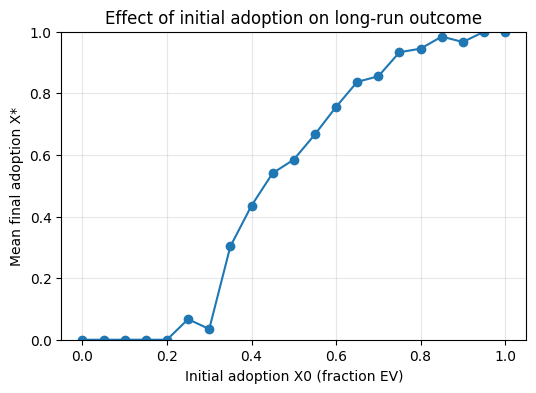

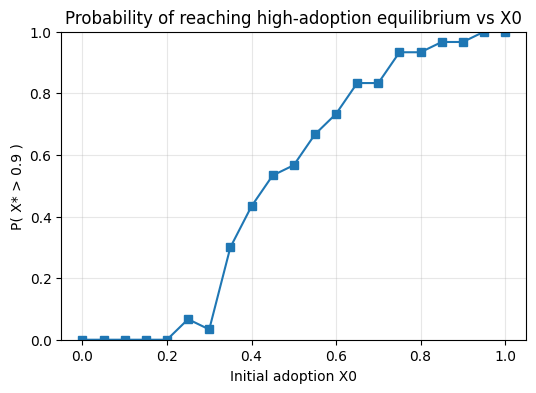

In [ ]:
X0_values = np.linspace(0.0, 1.0, 21)  # 0.00, 0.05, ..., 1.00
                                       # 21 refers to the number of time steps
mean_final_X, prob_high = sweep_X0_effect(
    X0_values,
    repeats=30,
    ratio=baseline_ratio,
    **baseline_params,
)

# Mean final adoption vs X0
plt.figure(figsize=(6,4))
plt.plot(X0_values, mean_final_X, marker="o")
plt.xlabel("Initial adoption X0 (fraction EV)")
plt.ylabel("Mean final adoption X*")
plt.title("Effect of initial adoption on long-run outcome")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

# Probability of high-adoption equilibrium vs X0
plt.figure(figsize=(6,4))
plt.plot(X0_values, prob_high, marker="s")
plt.xlabel("Initial adoption X0")
plt.ylabel("P( X* > 0.9 )")
plt.title("Probability of reaching high-adoption equilibrium vs X0")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

# 15. Influence of I0 on tipping boundary
# Production of heatmap of:
  ## Final adoption vs initial adoption
  ## Final adoption vs initial infrastructure

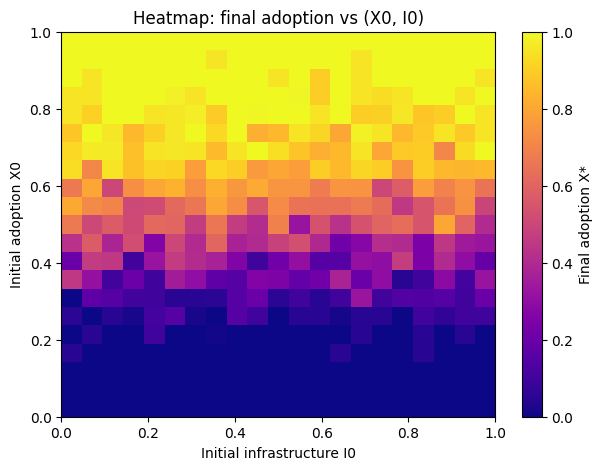

In [ ]:
# Influence of I0 on tipping boundary
# Production of heatmap of:
  # final adoption vs initial adoption
  # final adoption vs initial infrastructure

def heatmap_X0_I0(
    X0_values,
    I0_values,
    repeats=20,
    **fixed_params,
):
    """
    Compute a matrix final_X[i, j] = mean final adoption
    for X0_values[i], I0_values[j].
    """
    final_X = np.zeros((len(X0_values), len(I0_values)))

    for i, X0 in enumerate(X0_values):
        for j, I0 in enumerate(I0_values):
            finals = []
            for _ in range(repeats):
                seed_j = np.random.randint(0, 2**31 - 1)
                x_star = run_network_trial(
                    X0_frac=X0,
                    ratio=fixed_params["ratio"],
                    I0=I0,
                    beta_I=fixed_params["beta_I"],
                    b=fixed_params["b"],
                    g_I=fixed_params["g_I"],
                    T=fixed_params["T"],
                    network_type=fixed_params["network_type"],
                    n_nodes=fixed_params["n_nodes"],
                    p=fixed_params["p"],
                    m=fixed_params["m"],
                    seed=seed_j,
                    collect=False,
                    strategy_choice_func=fixed_params["strategy_choice_func"],
                    tau=fixed_params["tau"],
                )
                finals.append(x_star)
            final_X[i, j] = np.mean(finals)
    return final_X

    # Allows us to se how I0 (initial infrastructure) afects the tipping boundary

X0_values = np.linspace(0.0, 1.0, 21)
I0_values = np.linspace(0.0, 1.0, 21)  # choose a reasonable range for I0

final_X_matrix = heatmap_X0_I0(
    X0_values,
    I0_values,
    repeats=20,
    ratio=baseline_ratio,
    **baseline_params,
)

plt.figure(figsize=(7,5))
im = plt.imshow(
    final_X_matrix,
    origin="lower",
    extent=[I0_values[0], I0_values[-1], X0_values[0], X0_values[-1]],
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
    cmap="plasma",
)
plt.colorbar(im, label="Final adoption X*")
plt.xlabel("Initial infrastructure I0")
plt.ylabel("Initial adoption X0")
plt.title("Heatmap: final adoption vs (X0, I0)")
plt.show()

# 16. Phase plot sweeps for baseline system analysis

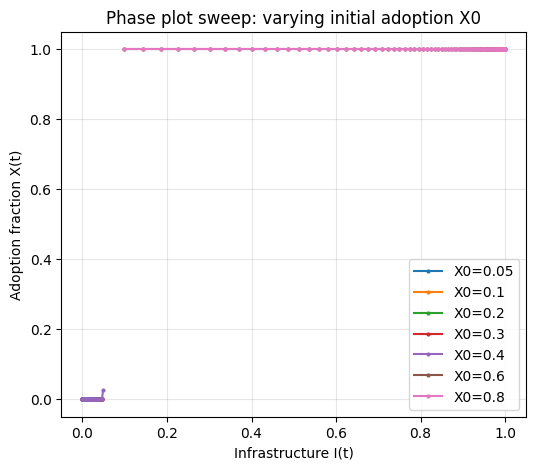


--- Final values for X0 sweep ---
  X0  X*           I*
0.05 0.0 1.348563e-07
0.10 0.0 1.348563e-07
0.20 0.0 1.348563e-07
0.30 0.0 1.348563e-07
0.40 0.0 1.384052e-07
0.60 1.0 9.999974e-01
0.80 1.0 9.999974e-01


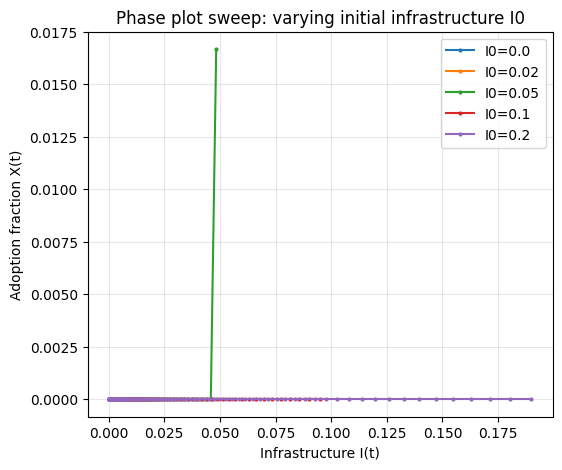


--- Final values for I0 sweep ---
  I0  X*           I*
0.00 0.0 0.000000e+00
0.02 0.0 5.394253e-08
0.05 0.0 1.372222e-07
0.10 0.0 2.697127e-07
0.20 0.0 5.394253e-07


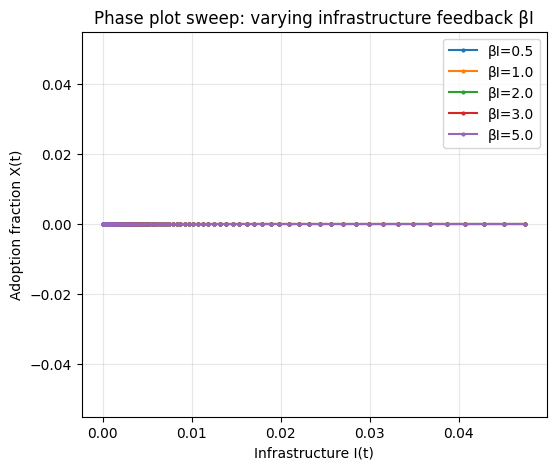


--- Final values for βI sweep ---
 βI  X*           I*
0.5 0.0 1.348563e-07
1.0 0.0 1.348563e-07
2.0 0.0 1.348563e-07
3.0 0.0 1.348563e-07
5.0 0.0 1.348563e-07


In [ ]:
# Phase plots of adoption X(t) and infrastructure I(t)
# This clearly shows how adoption responds to infrastructure changes
# This sweeps over different values for:
  # initial adoption (X0)
  # initial infrastructure (I0)
  # infrastructure feedback (Bi)
# Each sweep produces a multi-trajectory phase plot showing how adoption responds to infrastructure under different initial conditions
# With these we can identify tipping points and values of initial adoption and infrastructure that will give us evidence of tipping points for experimenting trajectories using similar X0 with different final outcomes
# This is for a random network type

# PHASE PLOT SWEEPS FOR BASELINE SYSTEM ANALYSIS
# Now includes numerical tables for X*(final) and I*(final)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make a clean copy of params_for_call without T and I0
# (so we don't pass T twice to run_phase_example)
params_for_phase = params_for_call.copy()
params_for_phase.pop("T", None)
params_for_phase.pop("I0", None)

# 1. Sweep over initial adoption X0

X0_values = [0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.80]
I0_fixed = 0.05

results_X0 = []   # store values for printing table

plt.figure(figsize=(6,5))
for X0 in X0_values:
    X, I, df = run_phase_example(
        X0_frac=X0,
        I0=I0_fixed,
        T=250,
        **params_for_phase
    )
    X_star = df["X"].iloc[-1]
    I_star = df["I"].iloc[-1]
    results_X0.append([X0, X_star, I_star])

    # clip I and X to [0,1] to avoid plotting artifacts
    I_plot = np.clip(df["I"].to_numpy(), 0.0, 1.0)
    X_plot = np.clip(df["X"].to_numpy(), 0.0, 1.0)

    plt.plot(I_plot, X_plot, marker="o", markersize=2, label=f"X0={X0}")

plt.xlabel("Infrastructure I(t)")
plt.ylabel("Adoption fraction X(t)")
plt.title("Phase plot sweep: varying initial adoption X0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print numerical table for X0 sweep
df_X0 = pd.DataFrame(results_X0, columns=["X0", "X*", "I*"])
print("\n--- Final values for X0 sweep ---")
print(df_X0.to_string(index=False))


# 2. Sweep over initial infrastructure I0

I0_values = [0.0, 0.02, 0.05, 0.10, 0.20]
X0_fixed = 0.20

results_I0 = []

plt.figure(figsize=(6,5))
for I0 in I0_values:
    X, I, df = run_phase_example(
        X0_frac=X0_fixed,
        I0=I0,
        T=250,
        **params_for_phase
    )
    X_star = df["X"].iloc[-1]
    I_star = df["I"].iloc[-1]
    results_I0.append([I0, X_star, I_star])

    # clip values
    I_plot = np.clip(df["I"].to_numpy(), 0.0, 1.0)
    X_plot = np.clip(df["X"].to_numpy(), 0.0, 1.0)

    plt.plot(I_plot, X_plot, marker="o", markersize=2, label=f"I0={I0}")

plt.xlabel("Infrastructure I(t)")
plt.ylabel("Adoption fraction X(t)")
plt.title("Phase plot sweep: varying initial infrastructure I0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print numerical table for I0 sweep
df_I0 = pd.DataFrame(results_I0, columns=["I0", "X*", "I*"])
print("\n--- Final values for I0 sweep ---")
print(df_I0.to_string(index=False))


# 3. Sweep over infrastructure feedback βI

beta_values = [0.5, 1.0, 2.0, 3.0, 5.0]
X0_fixed = 0.20
I0_fixed = 0.05

results_beta = []

plt.figure(figsize=(6,5))
for beta in beta_values:
    # create a temporary params dict with this beta_I
    params_temp = params_for_phase.copy()
    params_temp["beta_I"] = beta

    X, I, df = run_phase_example(
        X0_frac=X0_fixed,
        I0=I0_fixed,
        T=250,
        **params_temp
    )

    X_star = df["X"].iloc[-1]
    I_star = df["I"].iloc[-1]
    results_beta.append([beta, X_star, I_star])

    # clip values
    I_plot = np.clip(df["I"].to_numpy(), 0.0, 1.0)
    X_plot = np.clip(df["X"].to_numpy(), 0.0, 1.0)

    plt.plot(I_plot, X_plot, marker="o", markersize=2, label=f"βI={beta}")

plt.xlabel("Infrastructure I(t)")
plt.ylabel("Adoption fraction X(t)")
plt.title("Phase plot sweep: varying infrastructure feedback βI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print numerical table for beta_I sweep
df_beta = pd.DataFrame(results_beta, columns=["βI", "X*", "I*"])
print("\n--- Final values for βI sweep ---")
print(df_beta.to_string(index=False))


# 17. Phase plot sweeps near the critical threshold (X0 ≈ 0.40)

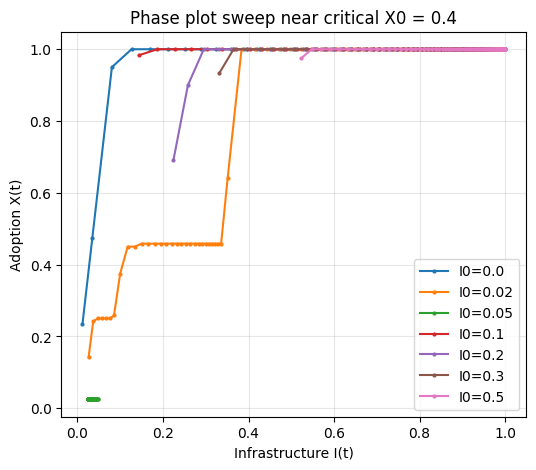


--- Final values for I0 sweep at critical X0 ---
  I0    X*       I*
0.00 1.000 0.999997
0.02 1.000 0.999992
0.05 0.025 0.025000
0.10 1.000 0.999998
0.20 1.000 0.999998
0.30 1.000 0.999998
0.50 1.000 0.999999


In [ ]:
# We will now generate phase plots with a fixed value of X = 0.40
# This is near the critical adoption threshold
# This will allow us to see the effect of the feedback infrastructure has on adoption when the loop is activated by X0

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# We choose a critical region X0 ≈ 0.40 (adjust to 0.35–0.45 if needed)
X0_critical = 0.40

params_for_phase = params_for_call.copy()
params_for_phase.pop("T", None)
params_for_phase.pop("I0", None)
params_for_phase.pop("ratio", None)   # <-- IMPORTANT for clean I0 sweep

# 1. Sweep over initial infrastructure I0

I0_values = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
results_I0_crit = []

plt.figure(figsize=(6,5))
for I0 in I0_values:
    X, I, df = run_phase_example(
        X0_frac=X0_critical,
        I0=I0,
        T=250,
        **params_for_phase  # Use params_for_phase which does not include T
    )

    X_star = df["X"].iloc[-1]
    I_star = df["I"].iloc[-1]
    results_I0_crit.append([I0, X_star, I_star])

    # NEW: clip values to valid range
    I_plot = np.clip(df["I"].to_numpy(), 0, 1)
    X_plot = np.clip(df["X"].to_numpy(), 0, 1)

    # --- THIS LINE WAS MISSING ---
    plt.plot(I_plot, X_plot, marker="o", markersize=2, label=f"I0={I0}")

# --- PRINT THE PLOT ---
plt.xlabel("Infrastructure I(t)")
plt.ylabel("Adoption X(t)")
plt.title(f"Phase plot sweep near critical X0 = {X0_critical}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print numerical table as before
df_I0_crit = pd.DataFrame(results_I0_crit, columns=["I0", "X*", "I*"])
print("\n--- Final values for I0 sweep at critical X0 ---")
print(df_I0_crit.to_string(index=False))


# 18. Sensitivity curves for different infrastructure feedback strength (βI)

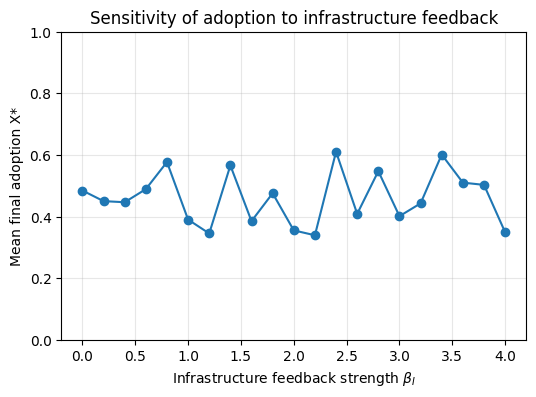

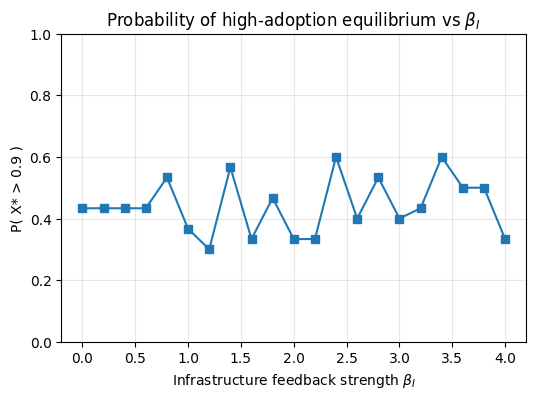

In [ ]:
# Sensitivity curves of final adoption vs Bi
# We fix X0 and I0 and sweep βI using run_network_trial

def sweep_beta_I_effect(
    beta_values,
    X0_frac,
    I0,
    repeats=20,
    high_threshold=0.9,
    **fixed_params,
):
    """
    For each beta_I in beta_values:
      - run `repeats` simulations
      - return:
          mean_final_X[beta_I]
          prob_high[beta_I] = P( final X* > high_threshold )
    """
    mean_final_X = []
    prob_high = []

    for beta_I in beta_values:
        finals = []
        for _ in range(repeats):
            seed_j = np.random.randint(0, 2**31 - 1)
            x_star = run_network_trial(
                X0_frac=X0_frac,
                ratio=fixed_params["ratio"],   # keep initial payoff ratio fixed
                I0=I0,
                beta_I=beta_I,
                b=fixed_params["b"],
                g_I=fixed_params["g_I"],
                T=fixed_params["T"],
                network_type=fixed_params["network_type"],
                n_nodes=fixed_params["n_nodes"],
                p=fixed_params["p"],
                m=fixed_params["m"],
                seed=seed_j,
                collect=False,
                strategy_choice_func=fixed_params["strategy_choice_func"],
                tau=fixed_params["tau"],
            )
            finals.append(x_star)

        finals = np.array(finals)
        mean_final_X.append(finals.mean())
        prob_high.append((finals > high_threshold).mean())

    return np.array(mean_final_X), np.array(prob_high)


# Run and plot sensitivity curves for varying βI

beta_values = np.linspace(0.0, 4.0, 21)
X0_for_beta = 0.45
I0_for_beta = 0.1

# Make a copy of baseline_params and adapt it for the βI sweep
beta_sweep_fixed_params = baseline_params.copy()
beta_sweep_fixed_params.pop("I0", None)      # I0 passed explicitly
beta_sweep_fixed_params.pop("beta_I", None)  # βI is what we sweep over
beta_sweep_fixed_params["ratio"] = baseline_ratio  # needed by run_network_trial

mean_final_X_beta, prob_high_beta = sweep_beta_I_effect(
    beta_values,
    X0_frac=X0_for_beta,
    I0=I0_for_beta,
    repeats=30,
    **beta_sweep_fixed_params,
)

# Mean final adoption vs βI
plt.figure(figsize=(6,4))
plt.plot(beta_values, mean_final_X_beta, marker="o")
plt.xlabel(r"Infrastructure feedback strength $\beta_I$")
plt.ylabel("Mean final adoption X*")
plt.title("Sensitivity of adoption to infrastructure feedback")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

# Probability of high adoption vs βI
plt.figure(figsize=(6,4))
plt.plot(beta_values, prob_high_beta, marker="s")
plt.xlabel(r"Infrastructure feedback strength $\beta_I$")
plt.ylabel(r"P( X* > 0.9 )")
plt.title(r"Probability of high-adoption equilibrium vs $\beta_I$")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()


# 19. Production of evidence of tipping points, path dependence, and bistability

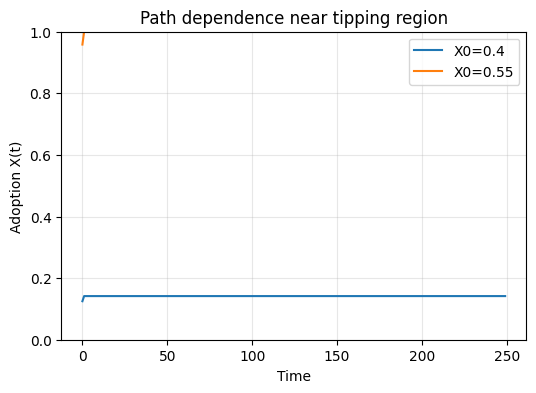

In [ ]:
# The sweeps allow us to:
  # choose regions where the curves change sharply
  # show trajectories with similar X0 (initial adopters) but different final outcomes
# we chose X(CHOOSE) just below and above the tipping threshold we observed in the X0 (initial adopters) sweep

X0_low = 0.40   # adjust based on where you see the jump
X0_high = 0.55

X_low, I_low, df_low = run_phase_example(
    X0_frac=X0_low,
    I0=baseline_params["I0"],
    T=250,
    **params_for_phase, # Changed from **params_for_call to **params_for_phase
)

X_high, I_high, df_high = run_phase_example(
    X0_frac=X0_high,
    I0=baseline_params["I0"],
    T=250,
    **params_for_phase, # Changed from **params_for_call to **params_for_phase
)

plt.figure(figsize=(6,4))
plt.plot(df_low.index, df_low["X"], label=f"X0={X0_low}")
plt.plot(df_high.index, df_high["X"], label=f"X0={X0_high}")
plt.xlabel("Time")
plt.ylabel("Adoption X(t)")
plt.title("Path dependence near tipping region")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 20. Network Structure Analysis

For each network type we will compare:
*  speed
*  probability of high adoption
*  cluster formation
*  tipping sensitivity

This code:
*  runs many trials per network type
*  computes 4 metrics (speed, probability of high adoption, cluster formation, tipping sensitivity)
*  Does a X0 (initial adoption) sweep per network type to identify *network specific sensitivity to tipping*

In this moment, the model supports random (Erdős–Rényi) and BA (scale-free) network types.

This code will work for any other network type (network_type) that we are interested in adding later.

In [ ]:
# Baseline settings for the Network Structure Analysis

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

HIGH_THRESHOLD = 0.9  # threshold for "high-adoption equilibrium"

STRUCT_BASELINE = dict(
    a0=2.0,
    beta_I=3.0,
    b=1.0,
    g_I=0.1,
    I0=0.05,
    n_nodes=120,
    p=0.05,
    m=2,
    strategy_choice_func="imitate",  # or "logit"
    tau=1.0,
)


In [ ]:
# Here we run the time series along with the model to identify clusters
# this runs the run_timeseries_trial and returns the model so the graph and clusters can be inspected

def run_timeseries_trial_with_model(
    T: int = 200,
    scenario_kwargs: dict | None = None,
    seed: int | None = None,
    policy=None,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
):
    """
    Same as run_timeseries_trial, but returns the model as well.
    """
    scenario = {
        "a0": 2.0,
        "ratio": None,
        "beta_I": 3.0,
        "b": 1.0,
        "g_I": 0.1,
        "I0": 0.05,
        "network_type": "random",
        "n_nodes": 100,
        "p": 0.05,
        "m": 2,
        "collect": True,
        "X0_frac": 0.0,
        "init_method": "random",
    }
    if scenario_kwargs:
        scenario.update(scenario_kwargs)

    # Compute a0 from ratio if provided
    a0_for_model = scenario["a0"]
    if scenario.get("ratio") is not None:
        a0_for_model = float(scenario["ratio"]) * float(scenario["b"]) - float(scenario["beta_I"]) * float(scenario["I0"])

    model = EVStagHuntModel(
        a0=a0_for_model,
        beta_I=scenario["beta_I"],
        b=scenario["b"],
        g_I=scenario["g_I"],
        I0=scenario["I0"],
        seed=seed,
        network_type=scenario["network_type"],
        n_nodes=scenario["n_nodes"],
        p=scenario["p"],
        m=scenario["m"],
        collect=True,
        strategy_choice_func=strategy_choice_func,
        tau=tau,
    )

    # Initial adoption
    if scenario.get("X0_frac", 0.0) > 0.0:
        set_initial_adopters(
            model,
            scenario["X0_frac"],
            method=scenario.get("init_method", "random"),
            seed=seed,
        )

    # Simulate
    for t in range(T):
        if policy is not None:
            policy(model, t)
        model.step()

    df = model.datacollector.get_model_vars_dataframe().copy()
    X = df["X"].to_numpy()
    I = df["I"].to_numpy()
    return X, I, df, model


In [ ]:
# Analyze speed, probability and clusters by network type
# This runs many trials for the selected network type and calculates speed, probability and clusters

def analyse_network_type(
    network_type: str,
    n_runs: int = 20,
    T: int = 200,
    X0_frac: float = 0.1,
    ratio: float = 2.0,
    high_threshold: float = HIGH_THRESHOLD,
    **base_params,
):
    """
    For a given network_type ('random', 'BA', later maybe 'small_world', 'grid'):
      - run n_runs simulations,
      - compute:
          final adoption distribution,
          probability of high-adoption equilibrium,
          time to reach high adoption,
          cluster statistics among EV adopters.
    """
    final_Xs = []
    times_to_high = []
    largest_cluster_fracs = []
    num_clusters_list = []

    for run in range(n_runs):
        seed = np.random.randint(0, 2**31 - 1)

        scenario_kwargs = {
            "a0": base_params["a0"],
            "ratio": ratio,
            "beta_I": base_params["beta_I"],
            "b": base_params["b"],
            "g_I": base_params["g_I"],
            "I0": base_params["I0"],
            "network_type": network_type,
            "n_nodes": base_params["n_nodes"],
            "p": base_params["p"],
            "m": base_params["m"],
            "collect": True,
            "X0_frac": X0_frac,
            "init_method": "random",
        }

        X, I, df, model = run_timeseries_trial_with_model(
            T=T,
            scenario_kwargs=scenario_kwargs,
            seed=seed,
            policy=None,
            strategy_choice_func=base_params["strategy_choice_func"],
            tau=base_params["tau"],
        )

        final_X = df["X"].iloc[-1]
        final_Xs.append(final_X)

        # speed of adoption: time to reach high threshold
        idxs = np.where(X >= high_threshold)[0]
        if len(idxs) > 0:
            times_to_high.append(int(idxs[0]))
        else:
            times_to_high.append(np.nan)

        # cluster formation at final time: EV adopters only
        ev_nodes = [a.unique_id for a in model.schedule.agents if a.strategy == "C"]
        n_nodes = model.G.number_of_nodes()

        if len(ev_nodes) == 0:
            largest_cluster_fracs.append(0.0)
            num_clusters_list.append(0)
        else:
            subG = model.G.subgraph(ev_nodes)
            num_clusters = nx.number_connected_components(subG)
            cluster_sizes = [len(c) for c in nx.connected_components(subG)]
            largest_cluster = max(cluster_sizes)
            largest_cluster_fracs.append(largest_cluster / n_nodes)
            num_clusters_list.append(num_clusters)

    final_Xs = np.array(final_Xs)
    times_to_high = np.array(times_to_high, dtype=float)
    largest_cluster_fracs = np.array(largest_cluster_fracs)
    num_clusters_list = np.array(num_clusters_list)

    results = {
        "network_type": network_type,
        "final_Xs": final_Xs,
        "times_to_high": times_to_high,
        "largest_cluster_fracs": largest_cluster_fracs,
        "num_clusters": num_clusters_list,
        "mean_final_X": float(np.nanmean(final_Xs)),
        "prob_high_adoption": float(np.mean(final_Xs >= high_threshold)),
        "mean_time_to_high": float(np.nanmean(times_to_high)),
        "mean_largest_cluster_frac": float(np.mean(largest_cluster_fracs)),
        "mean_num_clusters": float(np.mean(num_clusters_list)),
    }
    return results



In [ ]:
# Sweep over random and BA network types
# This gives us the:
  # probability of high adoption equilibrium
  # speed of adoption
  # cluster formation

network_types = ["random", "BA", "small_world", "grid"]   # 'random' = Erdős–Rényi, 'BA' = scale-free

all_results = {}
for net in network_types:
    print(f"Running network analysis for type='{net}'...")
    res = analyse_network_type(
        network_type=net,
        n_runs=30,
        T=200,
        X0_frac=0.1,
        ratio=2.0,
        **STRUCT_BASELINE,
    )
    all_results[net] = res


Running network analysis for type='random'...


/tmp/ipython-input-2253286688.py:93: RuntimeWarning: Mean of empty slice
  "mean_time_to_high": float(np.nanmean(times_to_high)),


Running network analysis for type='BA'...



Running network structure analysis...

Running network analysis for network='random' ...


/tmp/ipython-input-2253286688.py:93: RuntimeWarning: Mean of empty slice
  "mean_time_to_high": float(np.nanmean(times_to_high)),


Running network analysis for network='BA' ...
Running network analysis for network='small_world' ...
Running network analysis for network='grid' ...

--- All network simulations finished. ---

============== NETWORK COMPARISON SUMMARY ==============
    Network  Mean final X*  Prob high adoption  Mean time to high X  Mean largest cluster frac  Mean num clusters
     random       0.000278                 0.0                  NaN                   0.000278           0.033333
         BA       0.000000                 0.0                  NaN                   0.000000           0.000000
small_world       0.000278                 0.0                  NaN                   0.000278           0.033333
       grid       0.000278                 0.0                  NaN                   0.000278           0.033333


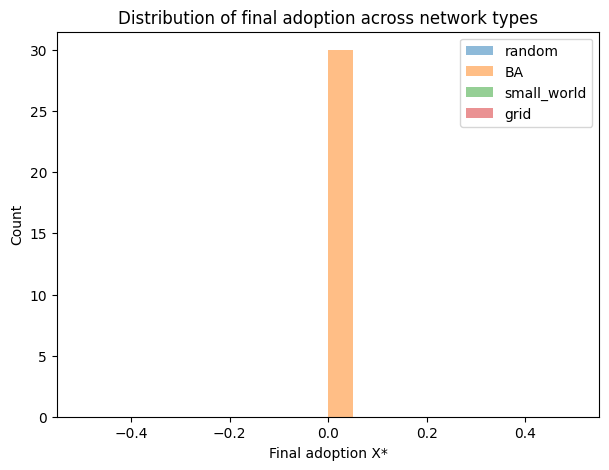

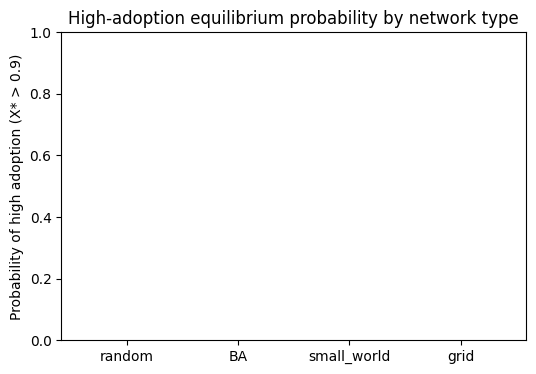

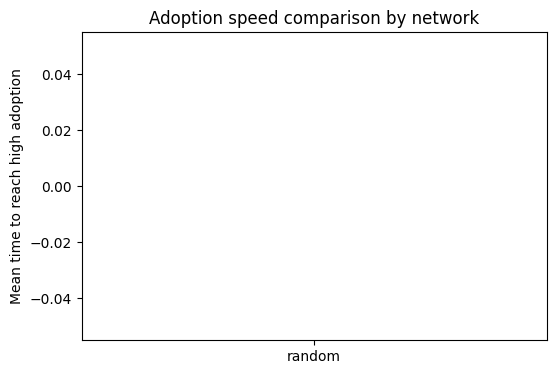

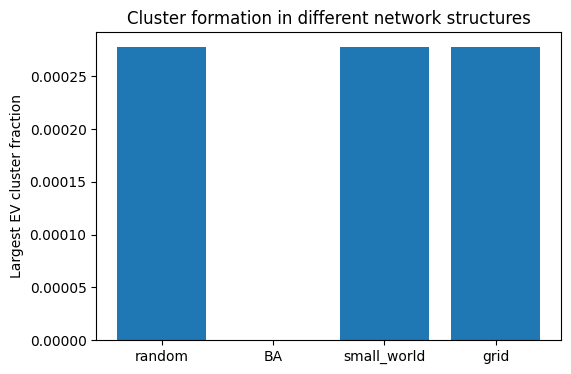

In [ ]:
# Network specific sensitivity to tipping
# We sweep X0 (initial adoption) for each network type
# We print a table with numerical results conserning:
  # Erdős–Rényi random, Barabási–Albert (scale-free), Watts–Strogatz small-world and 2D grid lattice
# This code:
  # Runs the experiment for all 4 model networks
  # Computes statistics
  # Builds a summary table
  # Produces comparison plots

import pandas as pd
import matplotlib.pyplot as plt

# Define all four network types required by the assignment
network_types = ["random", "BA", "small_world", "grid"]

all_results = {}

print("\nRunning network structure analysis...\n")

# Run analysis for each network type
for net in network_types:
    print(f"Running network analysis for network='{net}' ...")

    res = analyse_network_type(
        network_type=net,
        n_runs=30,             # number of runs for statistics
        T=200,                 # time horizon
        X0_frac=0.40,          # initial adoption
        ratio=2.0,             # payoff ratio
        **STRUCT_BASELINE      # your baseline parameters
    )

    all_results[net] = res

print("\n--- All network simulations finished. ---")

# SUMMARY TABLE

results_table = pd.DataFrame([
    {
        "Network": net,
        "Mean final X*": all_results[net]["mean_final_X"],
        "Prob high adoption": all_results[net]["prob_high_adoption"],
        "Mean time to high X": all_results[net]["mean_time_to_high"],
        "Mean largest cluster frac": all_results[net]["mean_largest_cluster_frac"],
        "Mean num clusters": all_results[net]["mean_num_clusters"]
    }
    for net in network_types
])

print("\n============== NETWORK COMPARISON SUMMARY ==============")
print(results_table.to_string(index=False))

# PLOTS

# Distribution of final adoption (X*)
plt.figure(figsize=(7,5))
for net in network_types:
    plt.hist(all_results[net]["final_Xs"], bins=20, alpha=0.5, label=net)

plt.xlabel("Final adoption X*")
plt.ylabel("Count")
plt.title("Distribution of final adoption across network types")
plt.legend()
plt.show()


# Probability of tipping (X* > 0.9)
plt.figure(figsize=(6,4))
plt.bar(network_types, [all_results[n]["prob_high_adoption"] for n in network_types])
plt.ylabel("Probability of high adoption (X* > 0.9)")
plt.title("High-adoption equilibrium probability by network type")
plt.ylim(0,1)
plt.show()


# Speed of adoption (mean time to reach high X)
plt.figure(figsize=(6,4))
plt.bar(network_types, [all_results[n]["mean_time_to_high"] for n in network_types])
plt.ylabel("Mean time to reach high adoption")
plt.title("Adoption speed comparison by network")
plt.show()


# Cluster formation (largest EV cluster fraction)
plt.figure(figsize=(6,4))
plt.bar(network_types, [all_results[n]["mean_largest_cluster_frac"] for n in network_types])
plt.ylabel("Largest EV cluster fraction")
plt.title("Cluster formation in different network structures")
plt.show()


# 21. Policy Intervention Design and Evaluation
*  Define targeted and timed policy
*  Compare:
  *  No intervention baseline
  *  Multiple intensities (different shock sizes)
  *  Different timings (early vs late)
  *  4 different network structures previously used
  


In [ ]:
# Baseline scenario for policy experiments (tweak if needed)
policy_baseline_scenario = {
    "a0": 2.0,
    "ratio": None,          # we use a0 directly
    "beta_I": 3.0,
    "b": 1.0,
    "g_I": 0.1,
    "I0": 0.05,
    "network_type": "random",   # will be overwritten in loops
    "n_nodes": 120,
    "p": 0.05,
    "m": 2,
    "collect": True,
    "X0_frac": 0.30,        # pick something near your tipping X0 (identified previously)
    "init_method": "random",
}


In [ ]:
# Sweep of policy scenerios with different policies, different network types and multiple random seeds

import numpy as np
import pandas as pd

def run_policy_experiment(
    network_type: str,
    policy,
    policy_label: str,
    scenario_base: dict,
    T: int = 200,
    n_runs: int = 20,
    strategy_choice_func: str = "imitate",
    tau: float = 1.0,
):
    """
    Run n_runs simulations for a given network_type and policy.
    Returns:
      - summary dict with mean final X*, prob high adoption, mean time to high
      - a DataFrame with per-run results
    """
    finals = []
    times_to_high = []
    records = []   # store per-time per-run traces if you want to plot later

    for run in range(n_runs):
        seed = np.random.randint(0, 2**31 - 1)

        scenario_kwargs = scenario_base.copy()
        scenario_kwargs["network_type"] = network_type

        X, I, df = run_timeseries_trial(
            T=T,
            scenario_kwargs=scenario_kwargs,
            seed=seed,
            policy=policy,
            strategy_choice_func=strategy_choice_func,
            tau=tau,
        )

        X_star = df["X"].iloc[-1]
        finals.append(X_star)

        # time to high adoption (if ever)
        idxs = np.where(X >= 0.9)[0]
        if len(idxs) > 0:
            times_to_high.append(int(idxs[0]))
        else:
            times_to_high.append(np.nan)

        # store trace (optional, useful for spaghetti/fan charts)
        df_temp = df.copy()
        df_temp["run"] = run
        df_temp["policy"] = policy_label
        df_temp["network_type"] = network_type
        records.append(df_temp)

    finals = np.array(finals)
    times_to_high = np.array(times_to_high, dtype=float)
    traces_df = pd.concat(records, ignore_index=True)

    summary = {
        "network_type": network_type,
        "policy": policy_label,
        "mean_final_X": float(np.nanmean(finals)),
        "prob_high_adoption": float(np.mean(finals >= 0.9)),
        "mean_time_to_high": float(np.nanmean(times_to_high)),
    }
    return summary, traces_df


In [ ]:
# Policy definition: baseline, timing (early/late), shocks (weak/strong)

# Baseline: no policy
policy_none = None

# Early infrastructure shocks (timed, different intensity)
policy_early_weak = policy_infrastructure_boost_factory(
    start=20,    # early in the simulation
    boost=0.1,   # weak boost
    once=True,
)

policy_early_strong = policy_infrastructure_boost_factory(
    start=20,
    boost=0.3,   # stronger boost
    once=True,
)

# Late infrastructure shock (timed, strong)
policy_late_strong = policy_infrastructure_boost_factory(
    start=120,   # later in the simulation
    boost=0.3,
    once=True,
)

# Pack them into a list of (label, policy) pairs
policy_scenarios = [
    ("baseline",                 policy_none),
    ("early_weak_infra_shock",   policy_early_weak),
    ("early_strong_infra_shock", policy_early_strong),
    ("late_strong_infra_shock",  policy_late_strong),
]

# RUN POLICY EXPERIMENTS ACROSS NETWORK TYPES
# This produces a data frame that gives us:
  # mean final X* (final adoption)
  # probability of high adoption
  # mean time to high x

all_policy_results = []
all_traces = []

for net in network_types:
    for label, pol in policy_scenarios:
        print(f"Running policy='{label}' on network='{net}'...")
        summary, traces_df = run_policy_experiment(
            network_type=net,
            policy=pol,
            policy_label=label,
            scenario_base=policy_baseline_scenario,
            T=200,
            n_runs=20,
            strategy_choice_func="imitate",
            tau=1.0,
        )
        all_policy_results.append(summary)
        all_traces.append(traces_df)

policy_results_df = pd.DataFrame(all_policy_results)
traces_all_df = pd.concat(all_traces, ignore_index=True)

print("\n=== Policy results summary ===")
print(policy_results_df.to_string(index=False))


In [ ]:
# Plots

# Policy per Network comparison: probability of high adoption

# Example: bar plot per network of P(high adoption) for each policy
for net in network_types:
    subset = policy_results_df[policy_results_df["network_type"] == net]
    plt.figure(figsize=(7,4))
    plt.bar(subset["policy"], subset["prob_high_adoption"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("P(X* > 0.9)")
    plt.title(f"Probability of high adoption – network={net}")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

# Compare timing (early vs late shocks)
# This helps us define which shocks (early/late, weak/strong) work better for the policy implementation

policy_results_df.sort_values(["network_type", "policy"], inplace=True)
print(policy_results_df[["network_type", "policy", "mean_final_X", "prob_high_adoption", "mean_time_to_high"]])


# 22. Policy Experiment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP: DEFINING THE "TESTING GROUNDS"
# We define specific "Starting Lines" (X0) for each network to ensure fair tests.
# - 'seeding_X0': A higher number used ONLY to compare Random vs. Targeted.
# - 'intervention_X0': A low number used to test if Subsidies/Infra can fix a failure.

network_settings = {
    "small_world": {
        "seeding_X0": 0.20,       # 20% initial users for Seeding comparisons
        "intervention_X0": 0.15   # 15% initial users for Policy interventions
    },
    "BA": {
        "seeding_X0": 0.40,       # BA needs 40% to be comparable in seeding
        "intervention_X0": 0.35   # 35% initial users for Policy interventions
    }
}

# Common Simulation Parameters
scenario_base = {
    "a0": 2.0, "b": 1.0, "beta_I": 3.0, "I0": 0.05, "g_I": 0.1,
    "n_nodes": 120, "p": 0.05, "m": 2,
    "collect": True
}


# 2. DEFINING THE STRATEGIES
def get_strategies(seeding_x, intervention_x):
    # --- ADD THIS LINE HERE ---
    # We must define n_targets BEFORE we use it in the list below
    n_targets = int(120 * 0.10)  # 10% of 120 nodes = 12
    # --------------------------

    return [
        # --- SEEDING COMPARISON ---
        {
            "name": "1. Seeding: Random",
            "X0_frac": seeding_x, "init_method": "random", "policy_def": None
        },
        {
            "name": "2. Seeding: Targeted",
            "X0_frac": seeding_x, "init_method": "degree", "policy_def": None
        },

        # --- SUBSIDY TESTS ---
        {
            "name": "3. Subsidy: Early (t=10)",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "subsidy",
                "params": {"start": 10, "end": 60, "delta_a0": 0.5}
            }
        },
        {
            "name": "4. Subsidy: Late (t=80)",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "subsidy",
                "params": {"start": 80, "end": 130, "delta_a0": 0.5}
            }
        },

        # --- INFRASTRUCTURE TESTS ---
        {
            "name": "5. Infra: Early (t=20)",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "infrastructure",
                "params": {"start": 20, "boost": 0.2, "once": True}
            }
        },
        {
            "name": "6. Infra: Late (t=100)",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "infrastructure",
                "params": {"start": 100, "boost": 0.2, "once": True}
            }
        },

        # --- TARGETED SUBSIDY TESTS ---
        {
            "name": "7. Targeted Sub: Hubs",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "targeted_subsidy",
                "params": {
                    "start": 10,
                    "end": 60,
                    "delta_a0": 1.5,
                    "num_targets": n_targets,  # <--- Now this works
                    "target_type": "degree"
                }
            }
        },
        {
            "name": "8. Targeted Sub: Rnd",
            "X0_frac": intervention_x, "init_method": "random",
            "policy_def": {
                "type": "targeted_subsidy",
                "params": {
                    "start": 10,
                    "end": 60,
                    "delta_a0": 1.5,
                    "num_targets": n_targets,  # <--- Now this works
                    "target_type": "random"
                }
            }
        }
    ]

# 3. RUNNING THE TOURNAMENT
results_data = []

print(f"Running Policy Tournament (Calibrated X0)...")

for net_name, settings in network_settings.items():
    print(f"\n--- Testing Network: {net_name.upper()} ---")

    # Generate strategies specific to this network's calibration
    strategies = get_strategies(settings['seeding_X0'], settings['intervention_X0'])

    for strategy in strategies:
        # Configure Run
        run_config = scenario_base.copy()
        run_config["network_type"] = net_name
        run_config["X0_frac"] = strategy["X0_frac"]
        run_config["init_method"] = strategy["init_method"]

        # Setup Policy
        pol_def = strategy["policy_def"]
        active_policy = None

        if pol_def:
            ptype = pol_def["type"]
            if ptype == "subsidy":
                active_policy = policy_subsidy_factory(**pol_def["params"])
            elif ptype == "infrastructure":
                active_policy = policy_infrastructure_boost_factory(**pol_def["params"])
            elif ptype == "seeding":
                active_policy = policy_seeding_factory(**pol_def["params"])
            elif ptype == "targeted_subsidy":  # <--- MAKE SURE THIS IS HERE
                active_policy = policy_targeted_subsidy_factory(**pol_def["params"])

        # Run Batch (20 trials)
        success_count = 0
        N_TRIALS = 200
        for _ in range(N_TRIALS):
            X, _, _ = run_timeseries_trial(
                T=250,
                scenario_kwargs=run_config,
                seed=None,
                policy=active_policy
            )
            # Check if it "tipped" (Reached > 90% adoption)
            if X[-1] > 0.90:
                success_count += 1

        rate = success_count / N_TRIALS
        results_data.append({
            "Network": net_name,
            "Strategy": strategy["name"],
            "Success Rate": rate
        })
        print(f"   {strategy['name'].ljust(25)}: {rate:.0%}")

# 4. VISUALIZATION
df_res = pd.DataFrame(results_data)
pivot_table = df_res.pivot(index="Strategy", columns="Network", values="Success Rate")

print("\n=== FINAL RESULTS TABLE ===")
print(pivot_table)

# Plot
ax = pivot_table.plot(kind="bar", figsize=(10, 6), width=0.8, color=['tab:blue', 'tab:orange'])
plt.title("Policy Effectiveness: Neighborhood (Small-World) vs. City (BA)")
plt.ylabel("Probability of Tipping (X > 0.9)")
plt.xlabel("Intervention Strategy")
plt.axhline(y=0.0, color='black', linewidth=1)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Topology")
plt.tight_layout()
plt.show()